In [1]:
# Importing necessary libraries

import pandas as pd
import duckdb 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Connecting to the DuckDB database

con = duckdb.connect("../01_docs/01_data/project.duckdb")

In [3]:
# Testing connection

con.execute("""
SELECT *
FROM read_parquet('../01_docs/01_data/02_intermediate/fhvhv_clean.parquet')
LIMIT 10
""").df()

,hvfhs_license_num,pickup_datetime,dropoff_datetime,request_datetime,on_scene_datetime,trip_distance,trip_time,pickup_location,dropoff_location,fare_amount,tip_amount,tolls_amount,airport_fee,driver_pay,shared_request_bool,shared_match_bool,wav_request_bool,wav_match_bool
0,Uber,2024-01-01 00:28:08,2024-01-01 01:05:39,2024-01-01 00:21:47,2024-01-01 00:25:06,2.83,2251,161,158,45.61,0.0,0.00,0.0,40.18,False,False,False,False
1,Uber,2024-01-01 00:12:53,2024-01-01 00:20:05,2024-01-01 00:10:56,2024-01-01 00:11:08,1.57,432,137,79,10.05,0.0,0.00,0.0,6.12,False,False,False,False
2,Uber,2024-01-01 00:23:05,2024-01-01 00:35:16,2024-01-01 00:20:04,2024-01-01 00:21:51,1.98,731,79,186,18.07,0.0,0.00,0.0,9.47,False,False,False,False
3,Uber,2024-01-01 00:41:04,2024-01-01 00:56:34,2024-01-01 00:35:46,2024-01-01 00:39:59,1.99,930,234,148,17.17,0.0,0.00,0.0,11.35,False,False,False,False
4,Uber,2024-01-01 00:57:21,2024-01-01 01:10:02,2024-01-01 00:48:19,2024-01-01 00:56:23,2.65,761,148,97,38.67,0.0,0.00,0.0,28.63,False,False,False,False
5,Uber,2024-01-01 00:06:15,2024-01-01 00:27:53,2024-01-01 00:03:47,2024-01-01 00:05:53,7.02,1298,255,95,32.16,0.0,0.00,0.0,24.35,False,False,False,True
6,Uber,2024-01-01 00:29:47,2024-01-01 00:50:08,2024-01-01 00:22:51,2024-01-01 00:29:17,11.33,1221,95,212,45.83,0.0,6.94,0.0,30.98,False,False,False,True
7,Uber,2024-01-01 00:57:50,2024-01-01 01:11:27,2024-01-01 00:45:34,2024-01-01 00:57:29,3.43,817,213,47,23.23,0.0,0.00,0.0,20.73,False,False,False,True
8,Uber,2024-01-01 00:16:00,2024-01-01 00:28:13,2024-01-01 00:11:51,2024-01-01 00:15:46,1.54,733,209,114,15.42,0.0,0.00,0.0,10.40,False,False,False,True
9,Uber,2024-01-01 00:33:15,2024-01-01 00:46:39,2024-01-01 00:26:48,2024-01-01 00:33:02,1.72,804,113,209,13.65,0.0,0.00,0.0,11.38,False,False,False,True


In [4]:
# Creating a view for easier querying

con.execute("""
            CREATE OR REPLACE VIEW trip_data AS
            SELECT *
            FROM read_parquet('../01_docs/01_data/02_intermediate/fhvhv_clean.parquet')
""")

In [5]:
# Checking trip count by pickup hour

trip_count_by_pickup_hour = con.execute(
"""
SELECT COUNT(*) AS trip_count,
    EXTRACT(HOUR FROM pickup_datetime) AS pickup_hour
FROM trip_data
GROUP BY pickup_hour
ORDER BY pickup_hour
""").df()

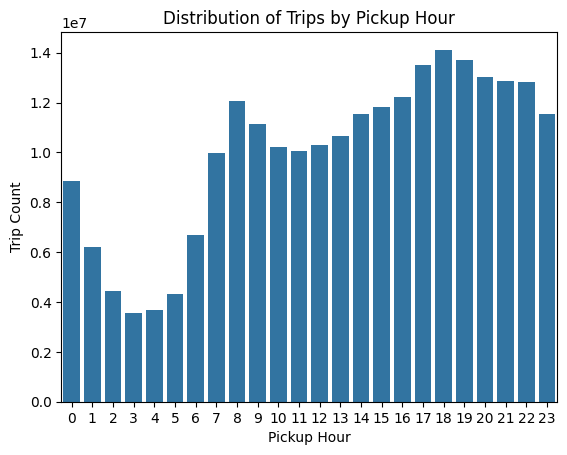

In [6]:
sns.barplot(data=trip_count_by_pickup_hour, x='pickup_hour', y='trip_count')
plt.title('Distribution of Trips by Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Trip Count')
plt.xticks(range(0, 24))
plt.show()

In [7]:
# Average trip time by pickup hour

avg_trip_time_by_pickup_hour = con.execute(
"""
SELECT AVG(trip_time)/60 AS avg_trip_duration,
       EXTRACT(HOUR FROM pickup_datetime) AS pickup_hour
FROM trip_data
GROUP BY pickup_hour
ORDER BY pickup_hour
""").df()

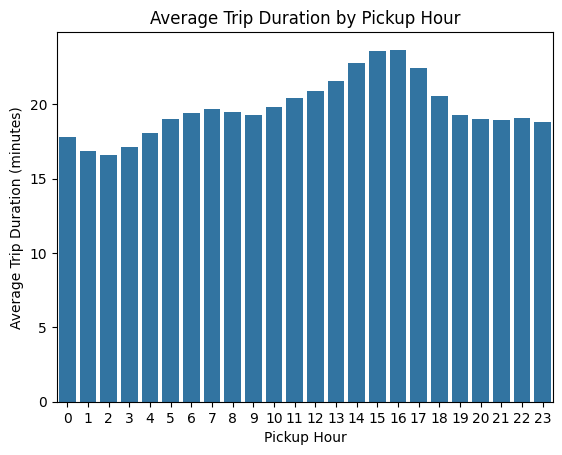

In [8]:
sns.barplot(data=avg_trip_time_by_pickup_hour, x='pickup_hour', y='avg_trip_duration')
plt.title('Average Trip Duration by Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Average Trip Duration (minutes)')
plt.xticks(range(0, 24))
plt.show()

In [9]:
# Average trip distance by pickup hour

avg_trip_distance_by_pickup_hour = con.execute(
"""
SELECT AVG(trip_distance) AS avg_trip_distance,
       EXTRACT(HOUR FROM pickup_datetime) AS pickup_hour
FROM trip_data
GROUP BY pickup_hour
ORDER BY pickup_hour
""").df()

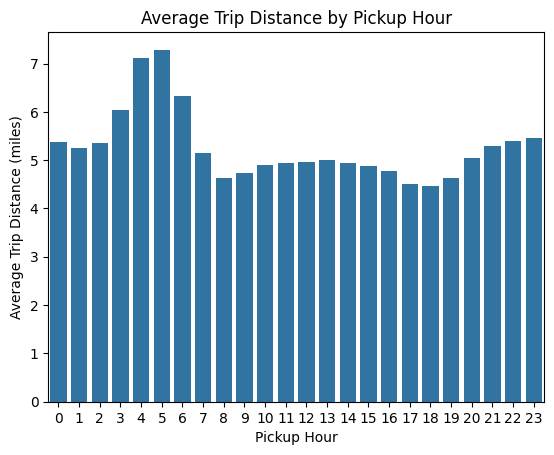

In [10]:

sns.barplot(data=avg_trip_distance_by_pickup_hour, x='pickup_hour', y='avg_trip_distance')
plt.title('Average Trip Distance by Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Average Trip Distance (miles)')
plt.xticks(range(0, 24))
plt.show()

In [53]:
# Average driver pay by time

average_driver_pay_by_time = con.execute(
"""
SELECT AVG(driver_pay) AS avg_driver_pay,
       EXTRACT(HOUR FROM pickup_datetime) AS pickup_hour
FROM trip_data
GROUP BY pickup_hour
""").df()

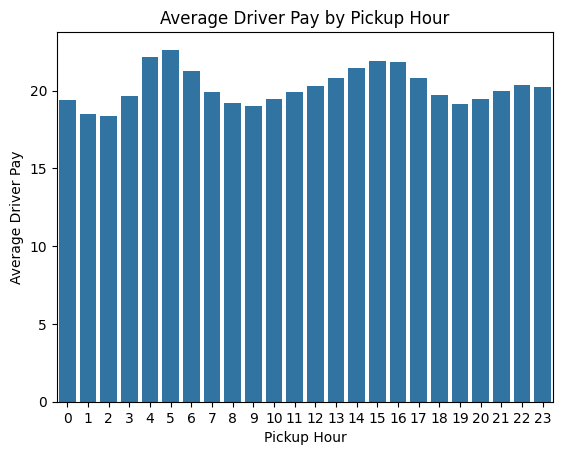

In [55]:
sns.barplot(data=average_driver_pay_by_time, x='pickup_hour', y='avg_driver_pay')
plt.title('Average Driver Pay by Pickup Hour')
plt.xlabel('Pickup Hour')
plt.ylabel('Average Driver Pay')
plt.xticks(range(0, 24))
plt.show()

In [40]:
# Trip count by pickup location

con.execute(
"""
CREATE OR REPLACE VIEW location_ids AS
SELECT LocationID, Borough, Zone
FROM read_csv_auto('../01_docs/03_guides/taxi_zone_lookup.csv')
""")

trip_count_by_pickup_location = con.execute(
"""
SELECT COUNT(*) AS trip_count,
       Borough AS pickup_location
FROM trip_data
LEFT JOIN location_ids
ON trip_data.pickup_location = location_ids.LocationID
GROUP BY location_ids.Borough
""").df()

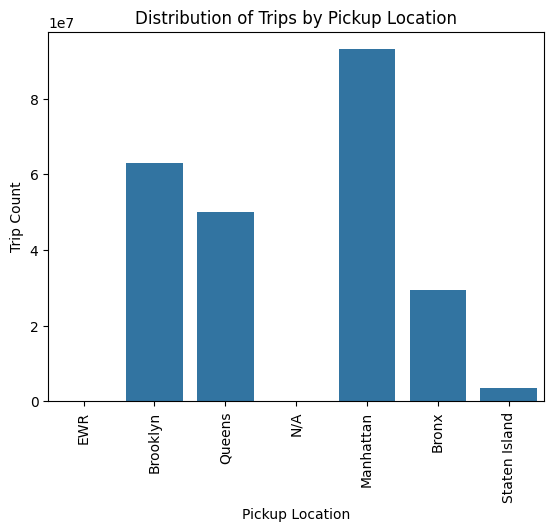

In [37]:
sns.barplot(data=trip_count_by_pickup_location, x='pickup_location', y='trip_count')
plt.title('Distribution of Trips by Pickup Location')
plt.xlabel('Pickup Location')
plt.ylabel('Trip Count')
plt.xticks(rotation=90)
plt.show()

In [51]:
# Top 30 pickup locations by trip count

top_30_pickup_locations = con.execute(
"""
SELECT COUNT(*) AS trip_count,
       Zone AS pickup_location,
       Borough AS borough
FROM trip_data
LEFT JOIN location_ids
ON trip_data.pickup_location = location_ids.LocationID
GROUP BY location_ids.Zone, location_ids.Borough
""").df().sort_values(by='trip_count', ascending=False).head(30)

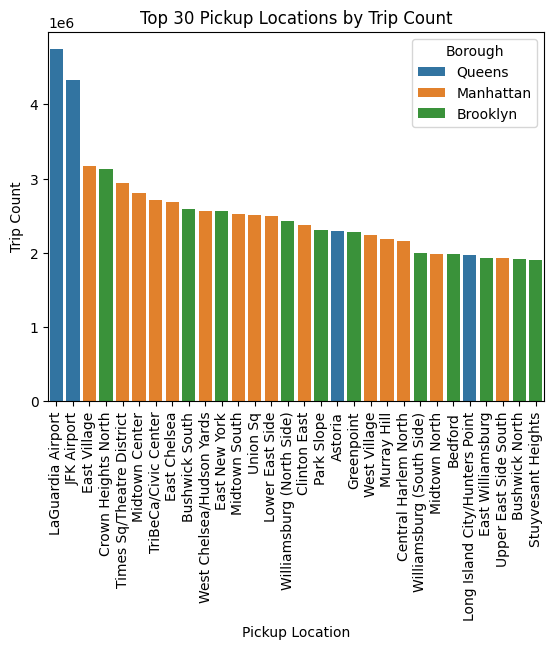

In [52]:
sns.barplot(data=top_30_pickup_locations, x='pickup_location', y='trip_count', hue='borough')
plt.title('Top 30 Pickup Locations by Trip Count') 
plt.xlabel('Pickup Location')
plt.ylabel('Trip Count')
plt.legend(title='Borough')
plt.xticks(rotation=90)
plt.show()

In [58]:
# Average driver pay by pickup location

average_driver_pay_by_pickup_location = con.execute(
"""
SELECT AVG(driver_pay) AS avg_driver_pay,
       Zone AS pickup_location,
       Borough AS borough
FROM trip_data
LEFT JOIN location_ids
ON trip_data.pickup_location = location_ids.LocationID
GROUP BY location_ids.Zone, location_ids.Borough
""").df()

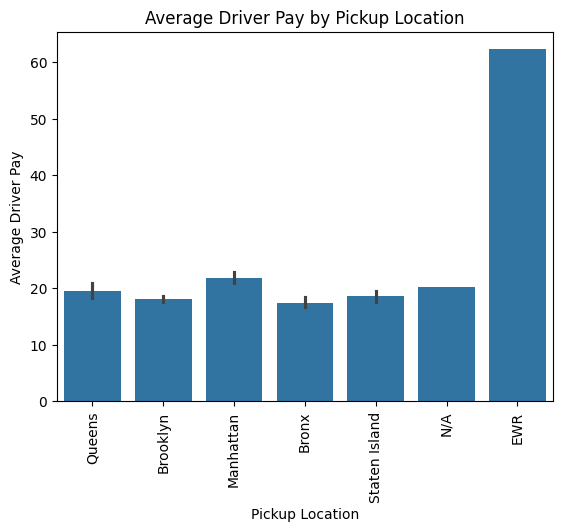

In [59]:
sns.barplot(data=average_driver_pay_by_pickup_location, x='borough', y='avg_driver_pay')
plt.title('Average Driver Pay by Pickup Location')
plt.xlabel('Pickup Location')
plt.ylabel('Average Driver Pay')
plt.xticks(rotation=90)
plt.show()

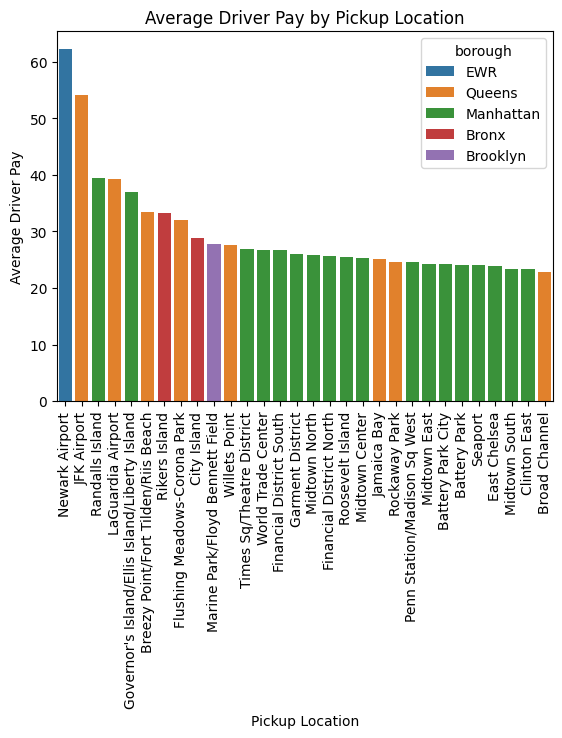

In [ ]:
sns.barplot(data=average_driver_pay_by_pickup_location.sort_values('avg_driver_pay', ascending=False).head(30), 
            x='pickup_location', y='avg_driver_pay', hue='borough')
plt.title('Average Driver Pay by Pickup Location')
plt.xlabel('Pickup Location')
plt.ylabel('Average Driver Pay')
plt.xticks(rotation=90)
plt.show()